In [1]:
import sys
sys.path.append('../../dataloaders/3W')
sys.path.append('../../../../3W')
import os
os.environ['path3W'] = '../../../'
import numpy as np
import pandas as pd
import torch

In [2]:
from loader import Loader3W
import importlib
importlib.reload(sys.modules['loader'])
import toolkit
importlib.reload(sys.modules['toolkit'])
ld = Loader3W()

In [ ]:
#ld.get_ids_from_wells_with_event_type([8])
#ld.load_stats()
#ld.extract_stats(['ABER-CKP', 'P-ANULAR', 'P-PDG','P-TPT','T-MON-CKP','T-PDG','T-TPT'])
#ld.save_stats()

In [3]:
ld.load_stats()
dg = ld.preprocess()

In [13]:
from tsdiffusion.ts_diffusion2 import TSDiffusion
importlib.reload(sys.modules['tsdiffusion.ts_diffusion2'])
ts_diffusion = TSDiffusion(
    in_channels=17,
    latent_dim=256,
    model_dim=256,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000
    )


In [ ]:
import torch
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
ts_diffusion.train3W(
    window_size=15,
    batch_size=4000,
    epochs=5,
)

Starting epoch 1/5 - dataset 1/9 - Partial Validation Loss: 0.098698
Ep 1: L1=-26.58 L2=0.30 L3=0.44 L4=0.00
Ep 1: L1=-34.03 L2=0.16 L3=0.41 L4=0.01
Ep 1: L1=-34.45 L2=0.10 L3=0.39 L4=0.07
Ep 1: L1=-34.43 L2=0.13 L3=0.40 L4=0.04
Ep 1: L1=-34.47 L2=0.13 L3=0.41 L4=0.03
Starting epoch 1/5 - dataset 2/9 - Partial Validation Loss: 0.139413
Ep 1: L1=-33.85 L2=0.28 L3=0.40 L4=0.02
Ep 1: L1=-34.46 L2=0.13 L3=0.39 L4=0.03
Ep 1: L1=-34.50 L2=0.09 L3=0.41 L4=0.03
Ep 1: L1=-34.51 L2=0.07 L3=0.40 L4=0.02
Ep 1: L1=-34.52 L2=0.06 L3=0.40 L4=0.01
Starting epoch 1/5 - dataset 3/9 - Partial Validation Loss: 0.084352
Ep 1: L1=-34.37 L2=0.21 L3=0.40 L4=0.01
Ep 1: L1=-34.38 L2=0.17 L3=0.43 L4=0.02
Ep 1: L1=-34.48 L2=0.11 L3=0.40 L4=0.03
Ep 1: L1=-34.51 L2=0.08 L3=0.40 L4=0.03
Ep 1: L1=-34.51 L2=0.07 L3=0.41 L4=0.02
Starting epoch 1/5 - dataset 4/9 - Partial Validation Loss: 0.092875
Ep 1: L1=-34.21 L2=0.27 L3=0.40 L4=0.00
Ep 1: L1=-34.47 L2=0.16 L3=0.42 L4=0.02
Ep 1: L1=-34.50 L2=0.09 L3=0.40 L4=0.02
Ep 1

In [ ]:
'''ts_diffusion = ts_diffusion.load('state.pt',in_channels=17,
    latent_dim=256,
    model_dim=256,
    static_dim=7,
    hidden_dim=1024,
    num_steps=1000)'''
ts_diffusion.save('state_ep10.pt')

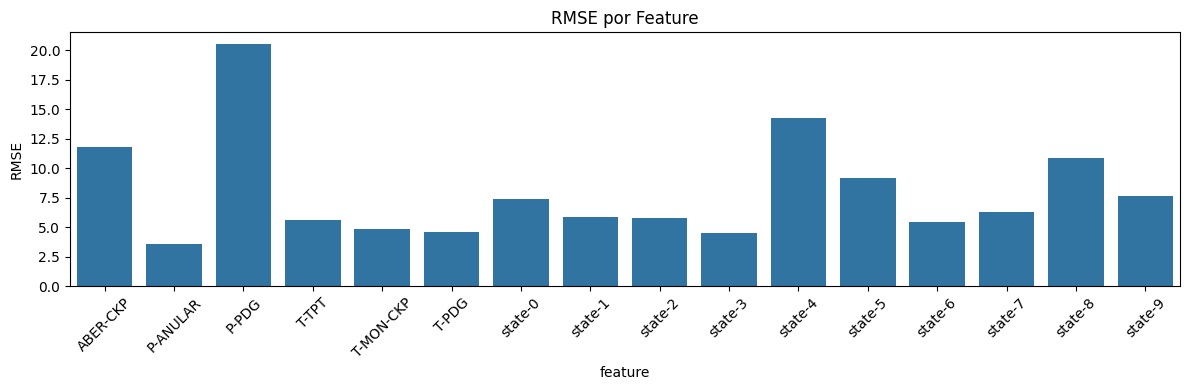

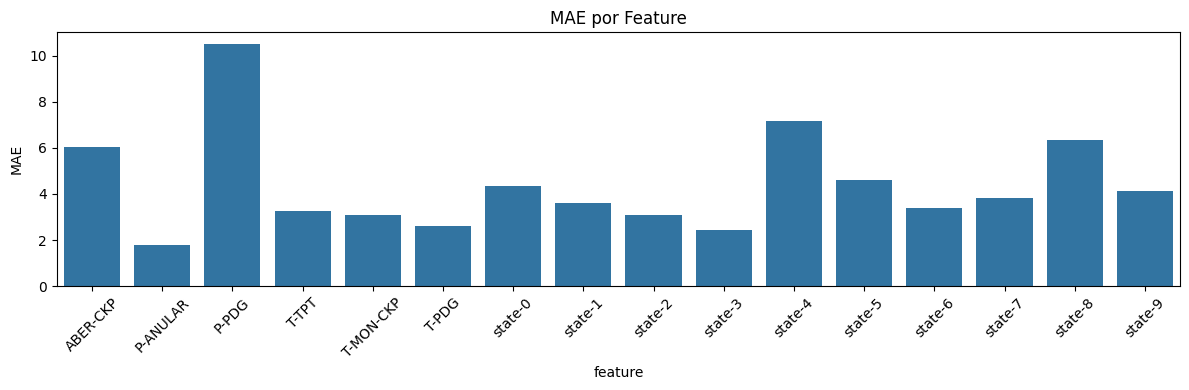

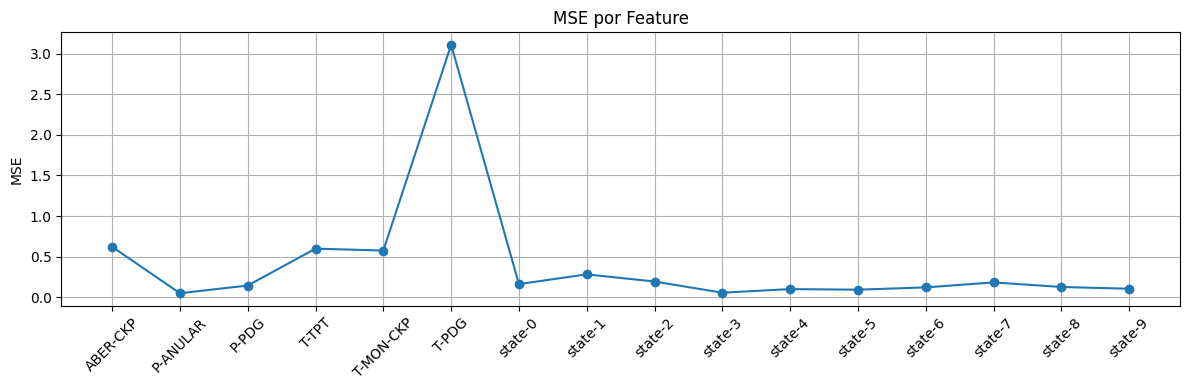

In [10]:
%matplotlib inline
ts_diffusion = ts_diffusion.to(device=torch.device('cuda'))
metrics = ts_diffusion.evaluate_datasets(
    test_datasets=2,
    window_size=15,
    batch_size=256,
    missing_frac=0.3,     # igual ao seu test_impute
    sampling_steps=50
)

# 2) Plota
ts_diffusion.plot_metrics_matplotlib(metrics)